# ML ground filtering s AFwizard

Tento notebook vysvetluje cele riesenie krok za krokom. Cielom nie je klasifikovat kazdy bod priamo modelom, ale naucit model vybrat najlepsi AFwizard filter pre dany segment point cloudu.

Zakladna myslienka:

```text
point cloud segment -> geometricke priznaky -> ML model -> AFwizard filter -> LASTools filtering -> DTM
```

## 1. Importy a cesty

Najprv si nastavime cesty k datam. PK dataset pouzivame na trening a overenie voci referencii. StA dataset pouzivame ako dalsi vstup, na ktorom sa ukaze, ze model vie priradit filter aj mimo PK.

In [55]:
from pathlib import Path
import json
import pandas as pd

from feature_extraction import FEATURE_NAMES, extract_training_samples, extract_tiled_feature_records
from ml_optimizer import MLFilterOptimizer
from filter_scoring import score_candidate_las
from rasterize_dtm import rasterize_ground_points

DATA_DIR = Path('data')
OUTPUT_DIR = Path('output')

PK_LAS = DATA_DIR / 'PK_last.laz'
PK_SEGMENTS = DATA_DIR / 'PK_segments.geojson'
PK_ASSIGNED = DATA_DIR / 'PK_segments_assigned.geojson'
REFERENCE_FILTERED = DATA_DIR / 'output' / 'PK_last_filtered.las'

MODEL_PATH = Path('optimizer_model.pkl')
ML_ASSIGNED = OUTPUT_DIR / 'PK_segments_ML_assigned.geojson'
ML_FILTERED = OUTPUT_DIR / 'PK_last_filtered.las'
ML_AFWIZARD_TIFF = OUTPUT_DIR / 'PK_last_filtered.tiff'
ML_DTM_TIFF = OUTPUT_DIR / 'PK_last_filtered_dtm.tiff'

STA_LAS = DATA_DIR / 'StA_last.laz'
STA_SEGMENTS = DATA_DIR / 'StA_segment.geojson'
STA_ML_ASSIGNED = OUTPUT_DIR / 'StA_segment_ML_assigned.geojson'
STA_FILTERED = OUTPUT_DIR / 'StA_last_filtered.las'
STA_DTM_TIFF = OUTPUT_DIR / 'StA_last_filtered_dtm.tiff'

paths = [PK_LAS, PK_SEGMENTS, PK_ASSIGNED, REFERENCE_FILTERED, STA_LAS, STA_SEGMENTS]
pd.DataFrame({'path': [str(p) for p in paths], 'exists': [p.exists() for p in paths]})

,path,exists
0,data/PK_last.laz,True
1,data/PK_segments.geojson,True
2,data/PK_segments_assigned.geojson,True
3,data/output/PK_last_filtered.las,True
4,data/StA_last.laz,True
5,data/StA_segment.geojson,True


## 2. Ake filtre ma model na vyber

Model vybera medzi AFwizard filtrami z kniznice `data/output`. V tomto projekte su dostupne dva filtre: jeden pre bezny/vegetacny teren a jeden pre vodny segment. AFwizard ich identifikuje cez `pipeline` hash, nie cez nazov suboru.

In [56]:
filter_files = [
    DATA_DIR / 'output' / 'ground_points_over_land.json',
    DATA_DIR / 'output' / 'ground_points_in_the_water.json',
]

rows = []
for path in filter_files:
    with open(path, 'r', encoding='utf-8') as f:
        config = json.load(f)
    rows.append({
        'file': str(path),
        'title': config.get('metadata', {}).get('title'),
        'backend': config.get('_backend'),
        'num_steps': len(config.get('filters', [])),
        'filters': config.get('filters', []),
    })

pd.DataFrame(rows)

,file,title,backend,num_steps,filters
0,data/output/ground_points_over_land.json,Ground points over land,pipeline,2,"[{'offset': 0.0, '_backend': 'lastools', 'spik..."
1,data/output/ground_points_in_the_water.json,Ground points in the water,pipeline,1,"[{'offset': 0.0, '_backend': 'lastools', 'spik..."


## 3. Referencne priradenie filtrov

`data/PK_segments_assigned.geojson` je trenovaci label dataset. Obsahuje, ktory filter bol referencne priradeny segmentu. Model sa uci prave z tychto priradeni.

In [57]:
with open(PK_ASSIGNED, 'r', encoding='utf-8') as f:
    assigned = json.load(f)

assigned_rows = []
for feature in assigned['features']:
    props = feature.get('properties', {})
    assigned_rows.append({
        'segment': props.get('segment'),
        'pipeline_title': props.get('pipeline_title'),
        'pipeline_hash': props.get('pipeline'),
    })

pd.DataFrame(assigned_rows)

,segment,pipeline_title,pipeline_hash
0,veg,Ground points over land,da3ef59d40b2853b00710542a0dc72c7d2ddc9da
1,UW,Ground points in the water,0f94f36544761b2337ee37a7b41d160290486ed2


## 4. Extrakcia trenovacich vzoriek

PK referencna segmentacia ma iba dva velke segmenty. Aby model nemal len dve vzorky, segmenty sa rozdelia na mensie dlazdice. Kazda dlazdica dedi label povodneho segmentu a z bodov v nej sa vypocitaju geometricke priznaky.

In [58]:
X_train, y_train, pipeline_titles, sample_records = extract_training_samples(
    str(PK_LAS),
    str(PK_ASSIGNED),
    cell_size=40.0,
    min_points=30,
)

samples_df = pd.DataFrame(sample_records)
print(f'Pocet trenovacich vzoriek: {len(X_train)}')
print(f'Pocet tried filtrov: {len(set(y_train))}')
samples_df.groupby(['segment_id', 'pipeline_title']).size().reset_index(name='tile_count')

Pocet trenovacich vzoriek: 129
Pocet tried filtrov: 2


,segment_id,pipeline_title,tile_count
0,UW,Ground points in the water,58
1,veg,Ground points over land,71


## 5. Ake priznaky sa pocitaju

Priznaky opisuju hustotu bodov, vyskovu variabilitu, roughness, sklon a podiel bodov nad lokalnym terenom. Model sa z nich uci rozlisit, ktory filter je vhodny pre aky typ segmentu.

In [59]:
feature_preview = pd.DataFrame(X_train, columns=FEATURE_NAMES)
feature_preview['pipeline_title'] = [pipeline_titles[p] for p in y_train]
feature_preview.head()

,log_point_count,density,z_std,z_range,z_p95_p05,z_iqr,plane_slope,plane_rmse,above_p10_1m_fraction,above_p10_3m_fraction,pipeline_title
0,7.032624,11.792204,1.192711,6.04,3.6190,1.3850,0.327412,0.946780,0.378092,0.103357,Ground points over land
1,8.929435,9.393037,1.582345,8.76,5.2600,2.0500,0.157958,1.208921,0.723576,0.247550,Ground points over land
2,7.604894,9.233172,1.715301,8.46,5.4900,2.3550,0.180315,1.071947,0.630294,0.256104,Ground points over land
3,7.463363,10.179497,1.161698,6.25,3.8200,1.5175,0.293846,0.778150,0.410448,0.078645,Ground points over land
4,9.238831,8.217288,2.176992,11.67,7.0465,3.2925,0.200250,1.220975,0.701983,0.388414,Ground points over land


## 6. Trening modelu

Pouziva sa `RandomForestClassifier`. Cielova trieda nie je nazov segmentu, ale AFwizard `pipeline` hash. Model teda predikuje, ktory filter ma AFwizard pouzit.

In [60]:
optimizer = MLFilterOptimizer(model_path=str(MODEL_PATH))
training_summary = optimizer.train_from_assigned_geojson(
    laz_path=str(PK_LAS),
    assigned_geojson_path=str(PK_ASSIGNED),
    cell_size=40.0,
    min_points=30,
)

training_summary

{'samples': 129,
 'classes': 2,
 'training_accuracy': 1.0,
 'class_counts': {'0f94f36544761b2337ee37a7b41d160290486ed2': 58,
  'da3ef59d40b2853b00710542a0dc72c7d2ddc9da': 71}}

## 7. Predikcia filtrov pre cielovu segmentaciu

`data/PK_segments.geojson` je segmentacia bez priradenych filtrov. Model pre kazdy segment vypocita priznaky po dlazdiciach a spriemeruje pravdepodobnosti filtrov.

In [61]:
target_records = extract_tiled_feature_records(
    str(PK_LAS),
    str(PK_SEGMENTS),
    cell_size=40.0,
    min_points=30,
)

prediction_rows = []
for record in target_records:
    prediction = optimizer.predict_from_samples(record['tile_features'])
    prediction_rows.append({
        'segment_id': record['segment_id'],
        'tiles': len(record['tile_features']),
        'pipeline_title': prediction.title,
        'pipeline_hash': prediction.pipeline,
        'confidence': round(prediction.confidence, 4),
        'requires_review': prediction.confidence < 0.7,
    })

prediction_df = pd.DataFrame(prediction_rows)
prediction_df

,segment_id,tiles,pipeline_title,pipeline_hash,confidence,requires_review
0,veg,71,Ground points over land,da3ef59d40b2853b00710542a0dc72c7d2ddc9da,0.9626,False
1,UW,58,Ground points in the water,0f94f36544761b2337ee37a7b41d160290486ed2,0.9522,False


## 8. Nazorne overenie automatickeho vyberu filtra

Automaticky vyber filtra sa da ukazat tak, ze ML predikciu porovname s referencnym rucnym priradenim filtrov. Ak model vyberie pre segment rovnaky `pipeline` hash ako referencia, znamena to, ze sa rozhodol rovnako ako operator/AFwizard treningove priradenie. Graf navyse ukazuje istotu modelu pre jednotlive filtre.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Polygon as MplPolygon


def show_once(fig):
    if fig is not None:
        plt.show()
        plt.close(fig)


def load_assignment_table(path, prefix):
    with open(path, 'r', encoding='utf-8') as f:
        geojson = json.load(f)

    rows = []
    for feature in geojson['features']:
        props = feature.get('properties', {})
        rows.append({
            'segment_id': props.get('segment') or props.get('id'),
            f'{prefix}_pipeline_title': props.get('pipeline_title'),
            f'{prefix}_pipeline_hash': props.get('pipeline'),
        })
    return pd.DataFrame(rows)


def prediction_probability_table(optimizer, records):
    rows = []
    class_labels = optimizer.label_encoder.inverse_transform(optimizer.model.classes_)
    for record in records:
        features = np.asarray(record['tile_features'], dtype=float)
        probabilities = optimizer.model.predict_proba(features).mean(axis=0)
        for class_index, pipeline_hash in enumerate(class_labels):
            rows.append({
                'segment_id': record['segment_id'],
                'pipeline_title': optimizer.pipeline_titles.get(pipeline_hash, pipeline_hash),
                'pipeline_hash': pipeline_hash,
                'probability': float(probabilities[class_index]),
            })
    return pd.DataFrame(rows)


reference_df = load_assignment_table(PK_ASSIGNED, 'reference')
ml_df = prediction_df.rename(columns={
    'pipeline_title': 'ml_pipeline_title',
    'pipeline_hash': 'ml_pipeline_hash',
})[['segment_id', 'ml_pipeline_title', 'ml_pipeline_hash', 'confidence']]

selection_check_df = reference_df.merge(ml_df, on='segment_id', how='outer')
selection_check_df['match'] = selection_check_df['reference_pipeline_hash'] == selection_check_df['ml_pipeline_hash']
selection_accuracy = selection_check_df['match'].mean()

probability_df = prediction_probability_table(optimizer, target_records)

display(selection_check_df[[
    'segment_id',
    'reference_pipeline_title',
    'ml_pipeline_title',
    'confidence',
    'match',
]])
print(f'Zhoda automatickeho vyberu s referenciou: {selection_accuracy:.1%}')

,segment_id,reference_pipeline_title,ml_pipeline_title,confidence,match
0,UW,Ground points in the water,Ground points in the water,0.9522,True
1,veg,Ground points over land,Ground points over land,0.9626,True


Zhoda automatickeho vyberu s referenciou: 100.0%


Ulozene: output/visualizations/ml_filter_selection_check.png


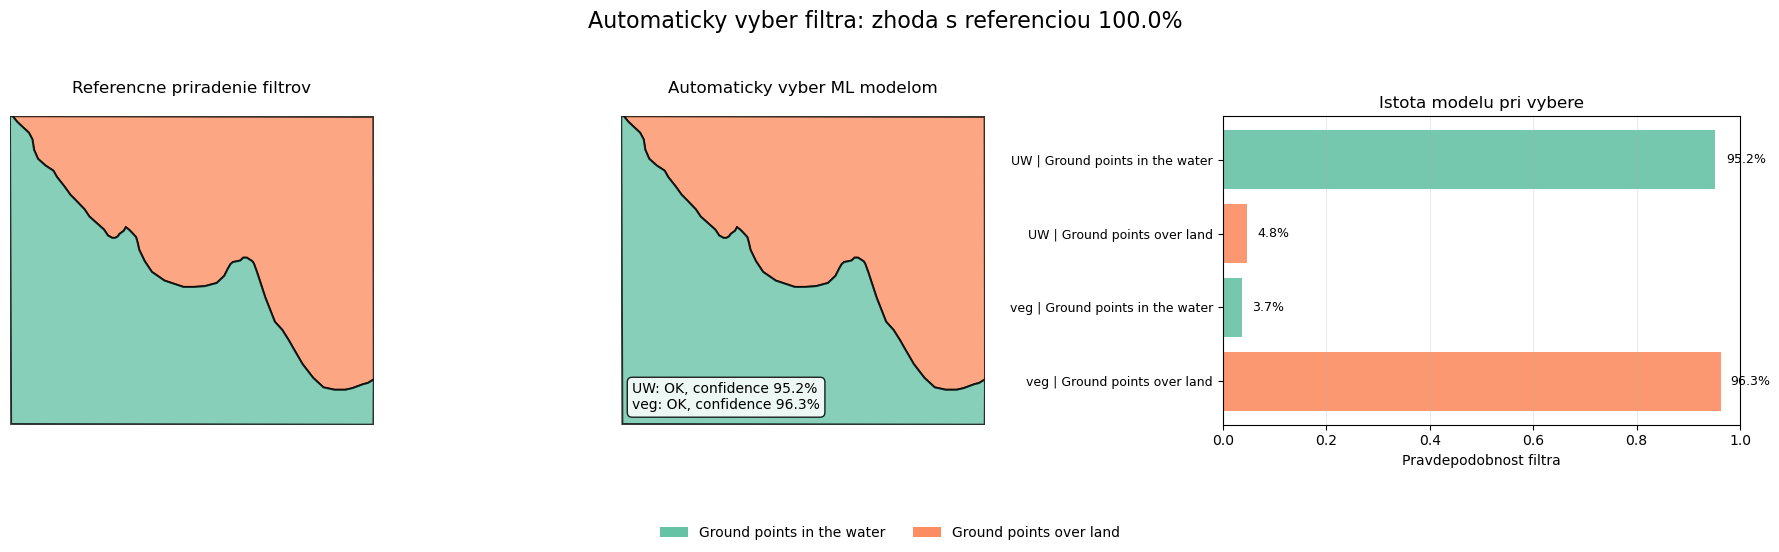

In [63]:
def exterior_rings(geometry):
    if geometry['type'] == 'Polygon':
        for polygon in [geometry['coordinates']]:
            yield polygon[0]
    elif geometry['type'] == 'MultiPolygon':
        for polygon in geometry['coordinates']:
            yield polygon[0]
    else:
        raise ValueError(f"Unsupported geometry type: {geometry['type']}")


def draw_assignment_map(ax, geojson_path, assignment_df, hash_column, title_column, title):
    with open(geojson_path, 'r', encoding='utf-8') as f:
        geojson = json.load(f)

    lookup = assignment_df.set_index('segment_id').to_dict(orient='index')
    all_x, all_y = [], []

    for feature in geojson['features']:
        props = feature.get('properties', {})
        segment_id = props.get('segment') or props.get('id')
        row = lookup[segment_id]
        pipeline_hash = row[hash_column]
        rings = list(exterior_rings(feature['geometry']))

        for ring in rings:
            xy = np.asarray(ring, dtype=float)
            all_x.extend(xy[:, 0])
            all_y.extend(xy[:, 1])
            patch = MplPolygon(
                xy,
                closed=True,
                facecolor=pipeline_colors[pipeline_hash],
                edgecolor='black',
                linewidth=1.4,
                alpha=0.78,
            )
            ax.add_patch(patch)

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min(all_x), max(all_x))
    ax.set_ylim(min(all_y), max(all_y))
    ax.axis('off')


def plot_automatic_selection_check(out_png=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1.0, 1.0, 1.35]})

    draw_assignment_map(
        axes[0],
        PK_ASSIGNED,
        reference_df,
        'reference_pipeline_hash',
        'reference_pipeline_title',
        'Referencne priradenie filtrov',
    )
    draw_assignment_map(
        axes[1],
        PK_SEGMENTS,
        ml_df,
        'ml_pipeline_hash',
        'ml_pipeline_title',
        'Automaticky vyber ML modelom',
    )

    result_lines = []
    for _, row in selection_check_df.iterrows():
        status = 'OK' if row['match'] else 'NESUHLAS'
        result_lines.append(f"{row['segment_id']}: {status}, confidence {row['confidence']:.1%}")
    axes[1].text(
        0.03,
        0.04,
        '\n'.join(result_lines),
        transform=axes[1].transAxes,
        ha='left',
        va='bottom',
        fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.86, 'boxstyle': 'round,pad=0.35'},
    )

    probability_plot_df = probability_df.sort_values(['segment_id', 'pipeline_title']).reset_index(drop=True)
    y_positions = np.arange(len(probability_plot_df))
    axes[2].barh(
        y_positions,
        probability_plot_df['probability'],
        color=[pipeline_colors[pipeline_hash] for pipeline_hash in probability_plot_df['pipeline_hash']],
        alpha=0.9,
    )
    axes[2].set_yticks(y_positions)
    axes[2].set_yticklabels(
        probability_plot_df['segment_id'] + ' | ' + probability_plot_df['pipeline_title'],
        fontsize=9,
    )
    for y, probability in zip(y_positions, probability_plot_df['probability']):
        axes[2].text(min(probability + 0.02, 0.98), y, f'{probability:.1%}', va='center', fontsize=9)
    axes[2].set_xlim(0, 1)
    axes[2].set_xlabel('Pravdepodobnost filtra')
    axes[2].set_title('Istota modelu pri vybere')
    axes[2].grid(axis='x', alpha=0.25)
    axes[2].invert_yaxis()

    legend_handles = [
        Patch(facecolor=pipeline_colors[pipeline_hash], label=title)
        for pipeline_hash, title in pipeline_titles_for_plot.items()
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)
    fig.suptitle(f'Automaticky vyber filtra: zhoda s referenciou {selection_accuracy:.1%}', fontsize=16)
    fig.tight_layout(rect=[0, 0.12, 1, 0.92])

    if out_png:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=180, bbox_inches='tight')
        print(f'Ulozene: {out_png}')

    return fig


pipeline_titles_for_plot = {}
for _, row in selection_check_df.iterrows():
    pipeline_titles_for_plot[row['reference_pipeline_hash']] = row['reference_pipeline_title']
    pipeline_titles_for_plot[row['ml_pipeline_hash']] = row['ml_pipeline_title']

palette = plt.get_cmap('Set2')
pipeline_colors = {
    pipeline_hash: palette(index)
    for index, pipeline_hash in enumerate(sorted(pipeline_titles_for_plot))
}

show_once(plot_automatic_selection_check(OUTPUT_DIR / 'visualizations' / 'ml_filter_selection_check.png'))

## 9. Zapis ML segmentacie

Nasledujuca bunka spusti hlavny workflow v dry-run rezime. To znamena, ze sa vykona trening, predikcia a zapis `output/PK_segments_ML_assigned.geojson`, ale nespusti sa tazka AFwizard/LASTools filtracia.

In [66]:
import importlib
import main

# Jupyter drzi moduly v pamati. Reload zabezpeci, ze bunka pouzije aktualny main.py.
main = importlib.reload(main)

main.automate_filtration_process(
    las_file=str(PK_LAS),
    geojson_file=str(PK_SEGMENTS),
    output_dir=str(OUTPUT_DIR),
    epsg='25833',
    lastools_dir=None,
    model_path=str(MODEL_PATH),
    train_las=str(PK_LAS),
    train_geojson=str(PK_ASSIGNED),
    filter_libraries=[str(DATA_DIR / 'output')],
    retrain=True,
    cell_size=40.0,
    min_points=30,
    confidence_threshold=0.7,
    run_afwizard=False,
)

ML_ASSIGNED.exists(), ML_ASSIGNED


Automated ML Point Cloud Ground Filtering
Dataset:      data/PK_last.laz
Segmentation: data/PK_segments.geojson
CRS:          EPSG:25833
Model:        optimizer_model.pkl

1. Training/loading the ML optimizer...
Trained model from assigned AFwizard segmentation (129 tiled samples, 2 classes, training accuracy=1.000).

2. Extracting tiled geometric features from target segments...
Extracted 129 tile feature vectors in 2 segments.

3. Predicting best AFwizard pipeline per segment...
   veg: Ground points over land (da3ef59d40b2853b00710542a0dc72c7d2ddc9da, confidence=0.96, tiles=71)
   UW: Ground points in the water (0f94f36544761b2337ee37a7b41d160290486ed2, confidence=0.95, tiles=58)

4. Writing ML-assigned AFwizard segmentation...
Saved: output/PK_segments_ML_assigned.geojson

5. AFwizard execution command...
/opt/conda/bin/python afwizard_fixed_cli.py --dataset=data/PK_last.laz --dataset-crs=EPSG:25833 --segmentation=output/PK_segments_ML_assigned.geojson --segmentation-crs=EPSG:25833

(True, PosixPath('output/PK_segments_ML_assigned.geojson'))

## 10. Volitelne spustenie AFwizard + LASTools

Tato cast je vypnuta, aby notebook omylom nespustil tazsi beh. Pre bezne pouzitie vo Windows PowerShell je najjednoduchsie spustit:

```powershell
.\run_pk_with_lastools.ps1 -LastoolsDir tools
```

Ak notebook bezi priamo v Docker kontajneri s namapovanym LASTools priecinkom ako `/lastools`, mozes nastavit `RUN_AFWIZARD = True`.

In [67]:
import importlib
import main

main = importlib.reload(main)

RUN_AFWIZARD = True

if RUN_AFWIZARD:
    main.automate_filtration_process(
        las_file=str(PK_LAS),
        geojson_file=str(PK_SEGMENTS),
        output_dir=str(OUTPUT_DIR),
        epsg='25833',
        lastools_dir='/lastools',
        model_path=str(MODEL_PATH),
        train_las=str(PK_LAS),
        train_geojson=str(PK_ASSIGNED),
        filter_libraries=[str(DATA_DIR / 'output')],
        retrain=True,
        cell_size=40.0,
        min_points=30,
        confidence_threshold=0.7,
        run_afwizard=True,
    )
else:
    print('AFwizard/LASTools beh je vypnuty. Spusti ho cez PowerShell launcher alebo nastav RUN_AFWIZARD = True.')


Automated ML Point Cloud Ground Filtering
Dataset:      data/PK_last.laz
Segmentation: data/PK_segments.geojson
CRS:          EPSG:25833
Model:        optimizer_model.pkl

1. Training/loading the ML optimizer...
Trained model from assigned AFwizard segmentation (129 tiled samples, 2 classes, training accuracy=1.000).

2. Extracting tiled geometric features from target segments...
Extracted 129 tile feature vectors in 2 segments.

3. Predicting best AFwizard pipeline per segment...
   veg: Ground points over land (da3ef59d40b2853b00710542a0dc72c7d2ddc9da, confidence=0.96, tiles=71)
   UW: Ground points in the water (0f94f36544761b2337ee37a7b41d160290486ed2, confidence=0.95, tiles=58)

4. Writing ML-assigned AFwizard segmentation...
Saved: output/PK_segments_ML_assigned.geojson

5. AFwizard execution command...
/opt/conda/bin/python afwizard_fixed_cli.py --dataset=data/PK_last.laz --dataset-crs=EPSG:25833 --segmentation=output/PK_segments_ML_assigned.geojson --segmentation-crs=EPSG:25833

## 11. Overenie zhody s referenciou

Po kompletnom behu sa porovna `output/PK_last_filtered.las` s referencnym `data/output/PK_last_filtered.las`. Porovnavaju sa ground body, teda body s `Classification == 2`.

In [68]:
if ML_FILTERED.exists():
    score_candidate_las(str(REFERENCE_FILTERED), str(ML_FILTERED))
else:
    print(f'{ML_FILTERED} este neexistuje. Najprv spusti .\\run_pk_with_lastools.ps1 -LastoolsDir tools')

## 12. Rasterizacia DTM

AFwizard po oprave vytvara `output/PK_last_filtered.tiff`. Navyse existuje aj pomocny skript `rasterize_dtm.py`, ktory berie iba body `Classification == 2` a vytvori DTM raster cez PDAL. Tento skript nerobi filtraciu, iba rasterizaciu uz klasifikovanych ground bodov.

In [69]:
RUN_DTM_RASTER = True

if RUN_DTM_RASTER and ML_FILTERED.exists():
    count = rasterize_ground_points(
        las_path=str(ML_FILTERED),
        output_tiff=str(ML_DTM_TIFF),
        epsg='25833',
        resolution=0.5,
    )
    print(f'Rasterized {count} ground points to {ML_DTM_TIFF}')
else:
    print('DTM rasterizacia je vypnuta alebo LAS vystup este neexistuje.')

Rasterized 519633 ground points to output/PK_last_filtered_dtm.tiff


## 13. Nazorna ukazka pred a po filtracii

Tato sekcia vytvori obrazok pre kazdy pouzity filter. Vlavo je povodny point cloud v danom segmente pred filtraciou. Vpravo je vysledok po automatickej filtracii: ground body `Classification == 2` su farebne a ostatne body su sive.

Ukazka je viazana na segmenty, ktore model priradil filtrom. V PK datasete tak uvidis priklad pre `Ground points over land` aj `Ground points in the water`.

Ulozeny obrazok: output/visualizations/pk_filters_before_after.png


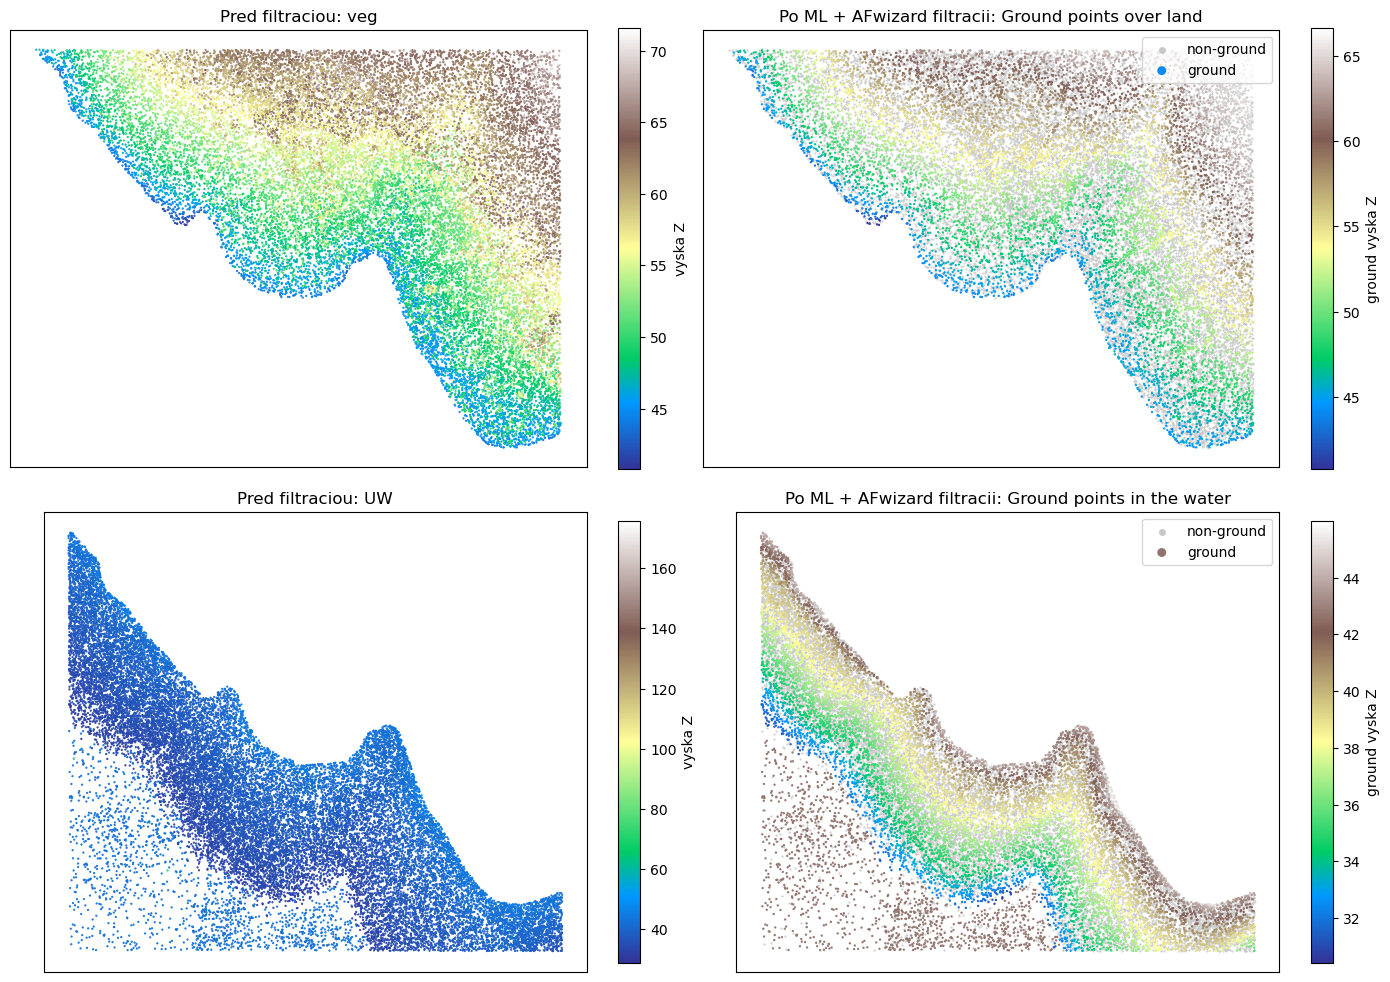

In [70]:
import numpy as np
import laspy
import matplotlib.pyplot as plt

from feature_extraction import _geometry_point_mask, _normalize_geometry


def load_xyz_classification(las_path):
    las = laspy.read(las_path)
    return (
        np.asarray(las.x),
        np.asarray(las.y),
        np.asarray(las.z),
        np.asarray(las.classification),
    )


def sample_indices(mask, max_points=25000, seed=42):
    indices = np.flatnonzero(mask)
    if indices.size <= max_points:
        return indices
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=max_points, replace=False))


def plot_filter_examples(raw_las_path, filtered_las_path, assigned_geojson_path, out_png=None):
    if not Path(filtered_las_path).exists():
        print(f'{filtered_las_path} este neexistuje. Najprv spusti .\\run_pk_with_lastools.ps1 -LastoolsDir tools')
        return None

    raw_x, raw_y, raw_z, _ = load_xyz_classification(raw_las_path)
    fil_x, fil_y, fil_z, fil_cls = load_xyz_classification(filtered_las_path)

    with open(assigned_geojson_path, 'r', encoding='utf-8') as f:
        assigned_geojson = json.load(f)

    features = assigned_geojson['features']
    fig, axes = plt.subplots(len(features), 2, figsize=(14, 5 * len(features)), squeeze=False)

    for row, feature in enumerate(features):
        props = feature.get('properties', {})
        segment_name = props.get('segment') or props.get('id') or f'segment {row}'
        pipeline_title = props.get('pipeline_title', 'unknown filter')
        geometry = _normalize_geometry(feature['geometry'])

        raw_mask = _geometry_point_mask(geometry, raw_x, raw_y)
        fil_mask = _geometry_point_mask(geometry, fil_x, fil_y)

        raw_idx = sample_indices(raw_mask)
        fil_idx = sample_indices(fil_mask)
        ground_idx = fil_idx[fil_cls[fil_idx] == 2]
        nonground_idx = fil_idx[fil_cls[fil_idx] != 2]

        ax_before = axes[row, 0]
        sc_before = ax_before.scatter(raw_x[raw_idx], raw_y[raw_idx], c=raw_z[raw_idx], s=0.35, cmap='terrain')
        ax_before.set_title(f'Pred filtraciou: {segment_name}')
        ax_before.set_aspect('equal', adjustable='box')
        ax_before.set_xticks([])
        ax_before.set_yticks([])
        fig.colorbar(sc_before, ax=ax_before, fraction=0.035, label='vyska Z')

        ax_after = axes[row, 1]
        if nonground_idx.size:
            ax_after.scatter(fil_x[nonground_idx], fil_y[nonground_idx], c='#c8c8c8', s=0.25, label='non-ground')
        if ground_idx.size:
            sc_after = ax_after.scatter(fil_x[ground_idx], fil_y[ground_idx], c=fil_z[ground_idx], s=0.45, cmap='terrain', label='ground')
            fig.colorbar(sc_after, ax=ax_after, fraction=0.035, label='ground vyska Z')
        ax_after.set_title(f'Po ML + AFwizard filtracii: {pipeline_title}')
        ax_after.set_aspect('equal', adjustable='box')
        ax_after.set_xticks([])
        ax_after.set_yticks([])
        ax_after.legend(loc='upper right', markerscale=8)

    fig.tight_layout()
    if out_png:
        Path(out_png).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=220, bbox_inches='tight')
        print(f'Ulozeny obrazok: {out_png}')
    return fig


show_once(plot_filter_examples(
    raw_las_path=PK_LAS,
    filtered_las_path=ML_FILTERED,
    assigned_geojson_path=ML_ASSIGNED,
    out_png=OUTPUT_DIR / 'visualizations' / 'pk_filters_before_after.png',
))

## 14. Rasterovy pohlad na scan pred a po filtracii

Scatter graf s bodmi je uzitocny technicky, ale pri obhajobe je lepsie ukazat pohlad podobny vyskovemu rastru. V tejto sekcii sa z bodov vytvori pravidelna mriezka. Pred filtraciou pouzijeme najvyssi bod v bunke, aby bolo vidiet vegetaciu a objekty. Po filtracii pouzijeme iba ground body a najnizsi bod v bunke, aby bolo vidiet teren po odfiltrovani.

Ulozeny obrazok: output/visualizations/pk_filters_raster_before_after.png


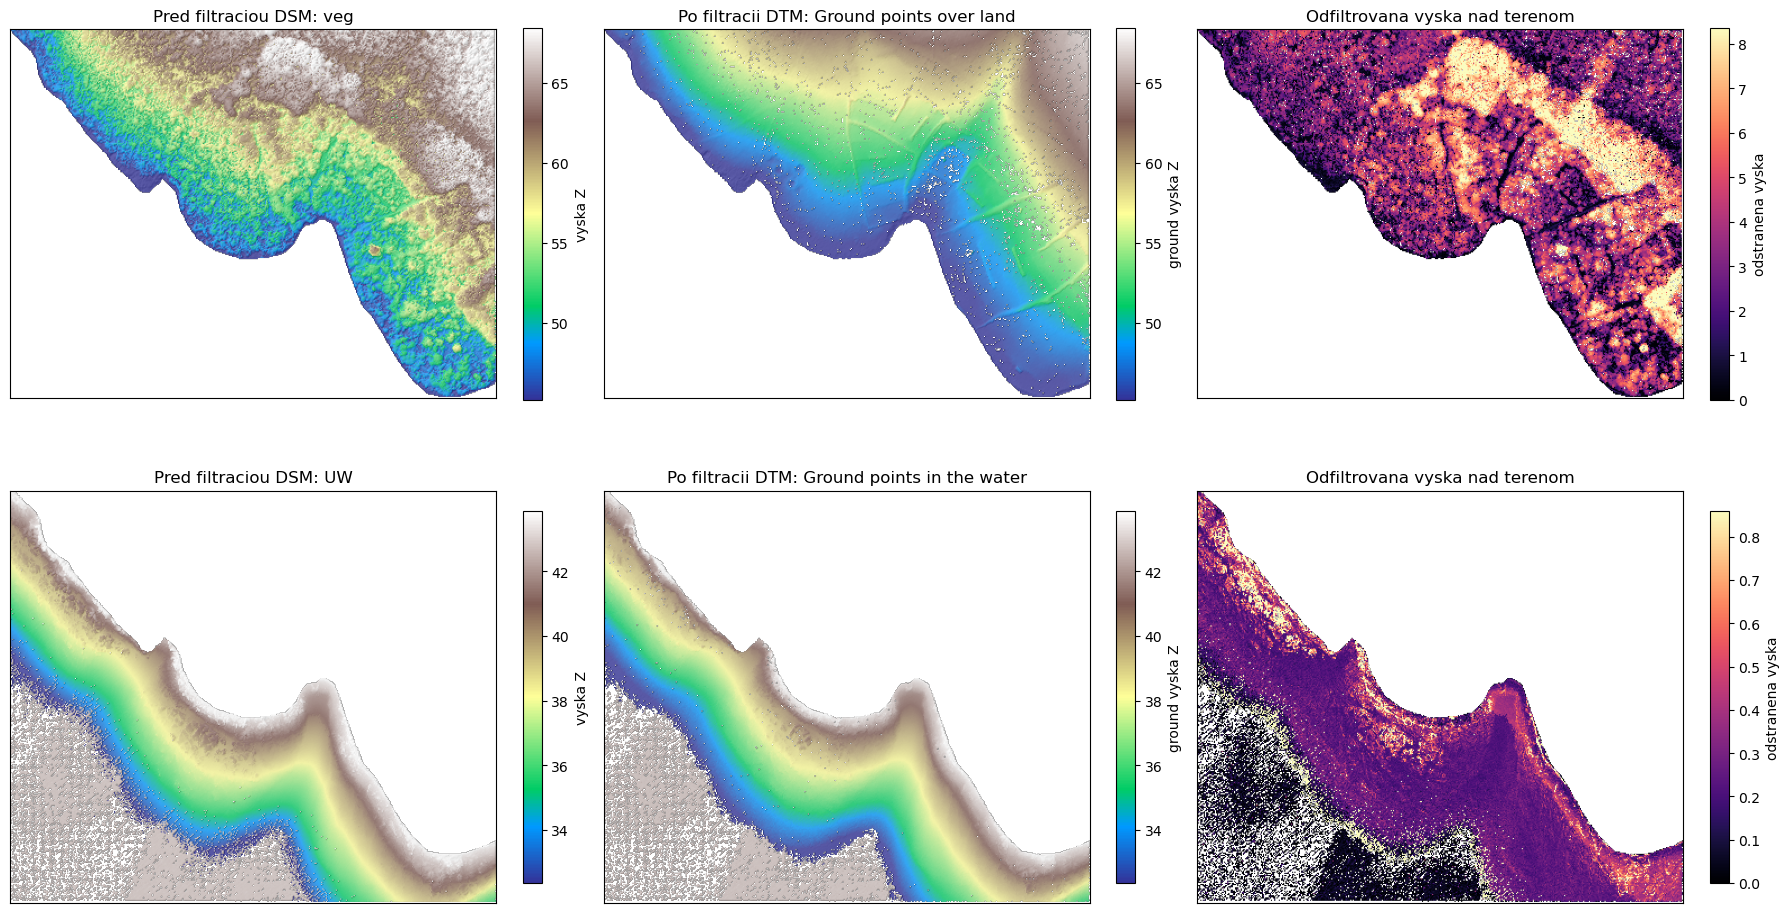

In [71]:
def raster_grid(x, y, z, resolution=1.0, mode='max', bounds=None):
    if bounds is None:
        minx, maxx = float(np.min(x)), float(np.max(x))
        miny, maxy = float(np.min(y)), float(np.max(y))
    else:
        minx, miny, maxx, maxy = bounds

    width = max(int(np.ceil((maxx - minx) / resolution)) + 1, 1)
    height = max(int(np.ceil((maxy - miny) / resolution)) + 1, 1)

    if mode == 'max':
        grid = np.full((height, width), -np.inf)
    else:
        grid = np.full((height, width), np.inf)

    cols = ((x - minx) / resolution).astype(int)
    rows = ((maxy - y) / resolution).astype(int)
    valid = (cols >= 0) & (cols < width) & (rows >= 0) & (rows < height)

    if mode == 'max':
        np.maximum.at(grid, (rows[valid], cols[valid]), z[valid])
        grid[~np.isfinite(grid)] = np.nan
    elif mode == 'min':
        np.minimum.at(grid, (rows[valid], cols[valid]), z[valid])
        grid[~np.isfinite(grid)] = np.nan
    else:
        raise ValueError("mode must be 'max' or 'min'")

    extent = [minx, maxx, miny, maxy]
    return grid, extent


def hillshade(grid, azimuth=315, altitude=45):
    filled = np.array(grid, dtype=float)
    nan_mask = np.isnan(filled)
    if np.all(nan_mask):
        return filled
    filled[nan_mask] = np.nanmedian(filled)
    dy, dx = np.gradient(filled)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    az = np.deg2rad(azimuth)
    alt = np.deg2rad(altitude)
    shaded = np.sin(alt) * np.sin(slope) + np.cos(alt) * np.cos(slope) * np.cos(az - aspect)
    shaded = (shaded - np.nanmin(shaded)) / max(np.nanmax(shaded) - np.nanmin(shaded), 1e-9)
    shaded[nan_mask] = np.nan
    return shaded


def plot_raster_filter_examples(raw_las_path, filtered_las_path, assigned_geojson_path, resolution=1.0, out_png=None):
    if not Path(filtered_las_path).exists():
        print(f'{filtered_las_path} este neexistuje. Najprv spusti .\\run_pk_with_lastools.ps1 -LastoolsDir tools')
        return None

    raw_x, raw_y, raw_z, _ = load_xyz_classification(raw_las_path)
    fil_x, fil_y, fil_z, fil_cls = load_xyz_classification(filtered_las_path)

    with open(assigned_geojson_path, 'r', encoding='utf-8') as f:
        assigned_geojson = json.load(f)

    features = assigned_geojson['features']
    fig, axes = plt.subplots(len(features), 3, figsize=(18, 5 * len(features)), squeeze=False)

    for row, feature in enumerate(features):
        props = feature.get('properties', {})
        segment_name = props.get('segment') or props.get('id') or f'segment {row}'
        pipeline_title = props.get('pipeline_title', 'unknown filter')
        geometry = _normalize_geometry(feature['geometry'])
        bounds = geometry.bounds

        raw_mask = _geometry_point_mask(geometry, raw_x, raw_y)
        fil_mask = _geometry_point_mask(geometry, fil_x, fil_y)
        ground_mask = fil_mask & (fil_cls == 2)
        removed_mask = fil_mask & (fil_cls != 2)

        raw_grid, extent = raster_grid(raw_x[raw_mask], raw_y[raw_mask], raw_z[raw_mask], resolution=resolution, mode='max', bounds=bounds)
        ground_grid, _ = raster_grid(fil_x[ground_mask], fil_y[ground_mask], fil_z[ground_mask], resolution=resolution, mode='min', bounds=bounds)
        removed_grid, _ = raster_grid(fil_x[removed_mask], fil_y[removed_mask], fil_z[removed_mask], resolution=resolution, mode='max', bounds=bounds)

        vmin = np.nanpercentile(raw_grid, 2)
        vmax = np.nanpercentile(raw_grid, 98)

        ax0, ax1, ax2 = axes[row]
        im0 = ax0.imshow(raw_grid, extent=extent, cmap='terrain', vmin=vmin, vmax=vmax)
        ax0.imshow(hillshade(raw_grid), extent=extent, cmap='gray', alpha=0.25)
        ax0.set_title(f'Pred filtraciou DSM: {segment_name}')

        im1 = ax1.imshow(ground_grid, extent=extent, cmap='terrain', vmin=vmin, vmax=vmax)
        ax1.imshow(hillshade(ground_grid), extent=extent, cmap='gray', alpha=0.25)
        ax1.set_title(f'Po filtracii DTM: {pipeline_title}')

        diff_grid = raw_grid - ground_grid
        im2 = ax2.imshow(diff_grid, extent=extent, cmap='magma', vmin=0, vmax=np.nanpercentile(diff_grid, 95))
        ax2.set_title('Odfiltrovana vyska nad terenom')

        for ax in (ax0, ax1, ax2):
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal', adjustable='box')

        fig.colorbar(im0, ax=ax0, fraction=0.035, label='vyska Z')
        fig.colorbar(im1, ax=ax1, fraction=0.035, label='ground vyska Z')
        fig.colorbar(im2, ax=ax2, fraction=0.035, label='odstranena vyska')

    fig.tight_layout()
    if out_png:
        Path(out_png).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=220, bbox_inches='tight')
        print(f'Ulozeny obrazok: {out_png}')
    return fig


show_once(plot_raster_filter_examples(
    raw_las_path=PK_LAS,
    filtered_las_path=ML_FILTERED,
    assigned_geojson_path=ML_ASSIGNED,
    resolution=1.0,
    out_png=OUTPUT_DIR / 'visualizations' / 'pk_filters_raster_before_after.png',
))

## 15. Nazorna ukazka pre StA ako novy dataset

StA sluzi ako ukazka pouzitia modelu mimo PK datasetu. Pre StA nemame v notebooku referencne rucne priradenie filtrov ako pri PK, preto tu neukazujeme percento zhody s operatorom. Ukazujeme vsak, ze model vezme novy point cloud a novu segmentaciu, vypocita priznaky, automaticky vyberie AFwizard filter a po spusteni AFwizard vznikne filtrovany vystup.

Ak este neexistuje `output/StA_last_filtered.las`, spusti v terminali:

```powershell
.\run_pk_with_lastools.ps1 -LastoolsDir tools -Las data/StA_last.laz -Geojson data/StA_segment.geojson -Epsg 31256 -DtmResolution 1.0
```

In [72]:
from feature_extraction import get_feature_identifier


sta_records = extract_tiled_feature_records(
    str(STA_LAS),
    str(STA_SEGMENTS),
    cell_size=40.0,
    min_points=30,
)

sta_prediction_rows = []
sta_predictions = {}
for record in sta_records:
    prediction = optimizer.predict_from_samples(record['tile_features'])
    sta_predictions[record['segment_id']] = prediction
    sta_prediction_rows.append({
        'segment_id': record['segment_id'],
        'tiles': len(record['tile_features']),
        'pipeline_title': prediction.title,
        'pipeline_hash': prediction.pipeline,
        'confidence': round(prediction.confidence, 4),
    })

with open(STA_SEGMENTS, 'r', encoding='utf-8') as f:
    sta_geojson = json.load(f)

for index, feature in enumerate(sta_geojson['features']):
    segment_id = get_feature_identifier(feature, index)
    prediction = sta_predictions[segment_id]
    props = feature.setdefault('properties', {})
    props['pipeline'] = prediction.pipeline
    props['pipeline_title'] = prediction.title
    props['pipeline_key'] = 'ml_optimizer'
    props['ml_confidence'] = round(prediction.confidence, 4)
    props['ml_confidence_threshold'] = 0.7
    props['ml_requires_review'] = prediction.confidence < 0.7
    if prediction.confidence < 0.7:
        props['ml_review_reason'] = 'Predicted filter confidence is below the configured threshold.'

STA_ML_ASSIGNED.parent.mkdir(parents=True, exist_ok=True)
with open(STA_ML_ASSIGNED, 'w', encoding='utf-8') as f:
    json.dump(sta_geojson, f, indent=2)

sta_prediction_df = pd.DataFrame(sta_prediction_rows)
sta_prediction_df

,segment_id,tiles,pipeline_title,pipeline_hash,confidence
0,segment_0,380,Ground points over land,da3ef59d40b2853b00710542a0dc72c7d2ddc9da,0.5405


Ulozene: output/visualizations/sta_filter_selection_check.png


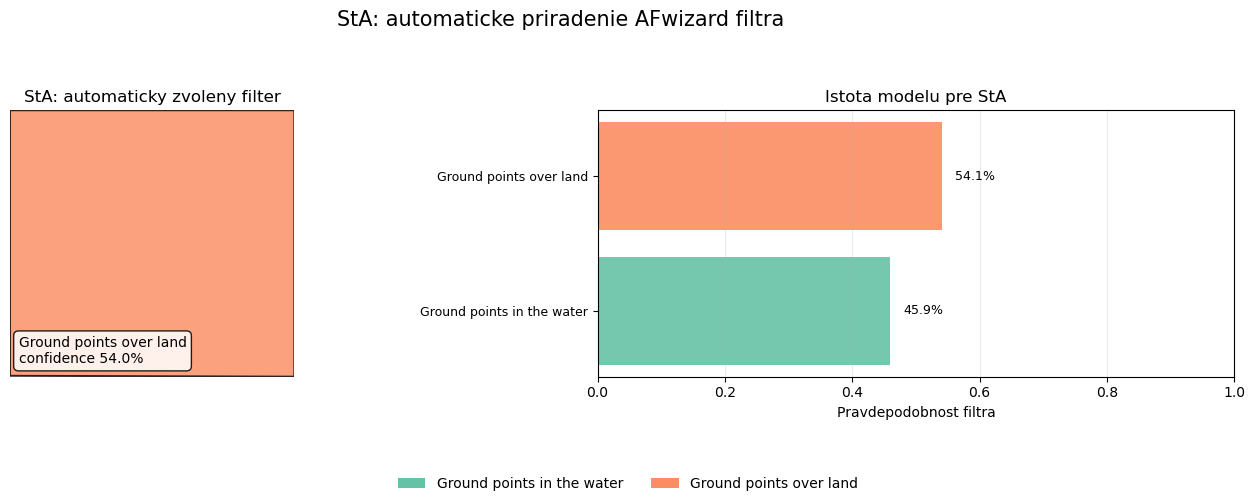

In [73]:
def probability_table_for_records(optimizer, records):
    rows = []
    class_labels = optimizer.label_encoder.inverse_transform(optimizer.model.classes_)
    for record in records:
        features = np.asarray(record['tile_features'], dtype=float)
        probabilities = optimizer.model.predict_proba(features).mean(axis=0)
        for class_index, pipeline_hash in enumerate(class_labels):
            rows.append({
                'segment_id': record['segment_id'],
                'pipeline_title': optimizer.pipeline_titles.get(pipeline_hash, pipeline_hash),
                'pipeline_hash': pipeline_hash,
                'probability': float(probabilities[class_index]),
            })
    return pd.DataFrame(rows)


def draw_single_assignment_map(ax, geojson_path, title):
    with open(geojson_path, 'r', encoding='utf-8') as f:
        geojson = json.load(f)

    all_x, all_y = [], []
    for feature in geojson['features']:
        props = feature.get('properties', {})
        pipeline_hash = props['pipeline']
        color = sta_pipeline_colors[pipeline_hash]

        for ring in exterior_rings(feature['geometry']):
            xy = np.asarray(ring, dtype=float)
            all_x.extend(xy[:, 0])
            all_y.extend(xy[:, 1])
            ax.add_patch(MplPolygon(xy, closed=True, facecolor=color, edgecolor='black', linewidth=1.4, alpha=0.82))

        label = f"{props.get('pipeline_title')}\nconfidence {props.get('ml_confidence'):.1%}"
        ax.text(
            0.03,
            0.04,
            label,
            transform=ax.transAxes,
            ha='left',
            va='bottom',
            fontsize=10,
            bbox={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.86, 'boxstyle': 'round,pad=0.35'},
        )

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min(all_x), max(all_x))
    ax.set_ylim(min(all_y), max(all_y))
    ax.axis('off')


def plot_sta_filter_selection(out_png=None):
    probability_df = probability_table_for_records(optimizer, sta_records)
    probability_df = probability_df.sort_values('probability', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.0, 1.15]})
    draw_single_assignment_map(axes[0], STA_ML_ASSIGNED, 'StA: automaticky zvoleny filter')

    y_positions = np.arange(len(probability_df))
    axes[1].barh(
        y_positions,
        probability_df['probability'],
        color=[sta_pipeline_colors[pipeline_hash] for pipeline_hash in probability_df['pipeline_hash']],
        alpha=0.9,
    )
    axes[1].set_yticks(y_positions)
    axes[1].set_yticklabels(probability_df['pipeline_title'], fontsize=9)
    for y, probability in zip(y_positions, probability_df['probability']):
        axes[1].text(min(probability + 0.02, 0.98), y, f'{probability:.1%}', va='center', fontsize=9)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Pravdepodobnost filtra')
    axes[1].set_title('Istota modelu pre StA')
    axes[1].grid(axis='x', alpha=0.25)

    legend_handles = [
        Patch(facecolor=sta_pipeline_colors[pipeline_hash], label=title)
        for pipeline_hash, title in sta_pipeline_titles.items()
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)
    fig.suptitle('StA: automaticke priradenie AFwizard filtra', fontsize=15)
    fig.tight_layout(rect=[0, 0.13, 1, 0.92])

    if out_png:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=180, bbox_inches='tight')
        print(f'Ulozene: {out_png}')

    return fig


sta_pipeline_titles = {
    row['pipeline_hash']: row['pipeline_title']
    for _, row in probability_table_for_records(optimizer, sta_records).iterrows()
}
sta_palette = plt.get_cmap('Set2')
sta_pipeline_colors = {
    pipeline_hash: sta_palette(index)
    for index, pipeline_hash in enumerate(sorted(sta_pipeline_titles))
}

show_once(plot_sta_filter_selection(OUTPUT_DIR / 'visualizations' / 'sta_filter_selection_check.png'))

### StA benchmark kandidatskych filtrov podla referencneho DTM

Toto je silnejsie overenie pre StA. Spustia sa vsetky dostupne AFwizard filtre, z kazdeho vystupu sa vytvori DTM a ten sa porovna s referencnym `data/StA_last_dtm.tiff`. Najlepsi filter je ten s najnizsou RMSE chybou. Tazky benchmark sa nespusta automaticky v notebooku; vysledky sa citaju z `output/benchmarks/sta/candidate_metrics.csv`.

Benchmark spustis prikazom:

```powershell
docker run --rm --entrypoint /usr/local/bin/_entrypoint.sh -v "${PWD}:/app" -v "${PWD}\tools:/lastools:ro" -e LASTOOLS_DIR=/lastools -e LD_LIBRARY_PATH=/lastools/bin/lib:/lastools/lib:/opt/conda/lib -w /app ml-groundfiltering-app python benchmark_filters.py --las data/StA_last.laz --geojson data/StA_segment.geojson --reference-dtm data/StA_last_dtm.tiff --epsg 31256 --library data/output --outdir output/benchmarks/sta --lastools-dir /lastools --resolution 1.0 --run-afwizard
```

In [74]:
STA_BENCHMARK_CSV = OUTPUT_DIR / 'benchmarks' / 'sta' / 'candidate_metrics.csv'

if not STA_BENCHMARK_CSV.exists():
    print(f'{STA_BENCHMARK_CSV} este neexistuje. Spusti benchmark prikaz z markdown bunky vyssie.')
else:
    sta_benchmark_df = pd.read_csv(STA_BENCHMARK_CSV)
    display(sta_benchmark_df[[
        'rank',
        'pipeline_title',
        'rmse',
        'mae',
        'bias',
        'coverage_ratio',
    ]])

    ml_sta_filter = sta_prediction_df.sort_values('confidence', ascending=False).iloc[0]['pipeline_hash']
    benchmark_best_filter = sta_benchmark_df.sort_values('rank').iloc[0]['pipeline_hash']
    print('ML vyber sa zhoduje s najlepsim DTM benchmark filtrom:', ml_sta_filter == benchmark_best_filter)

,rank,pipeline_title,rmse,mae,bias,coverage_ratio
0,1,Ground points over land,0.322467,0.039790,0.003978,0.978791
1,2,Ground points in the water,0.331733,0.037389,0.011437,0.978782


ML vyber sa zhoduje s najlepsim DTM benchmark filtrom: True


Ulozene: output/visualizations/sta_benchmark_metrics.png


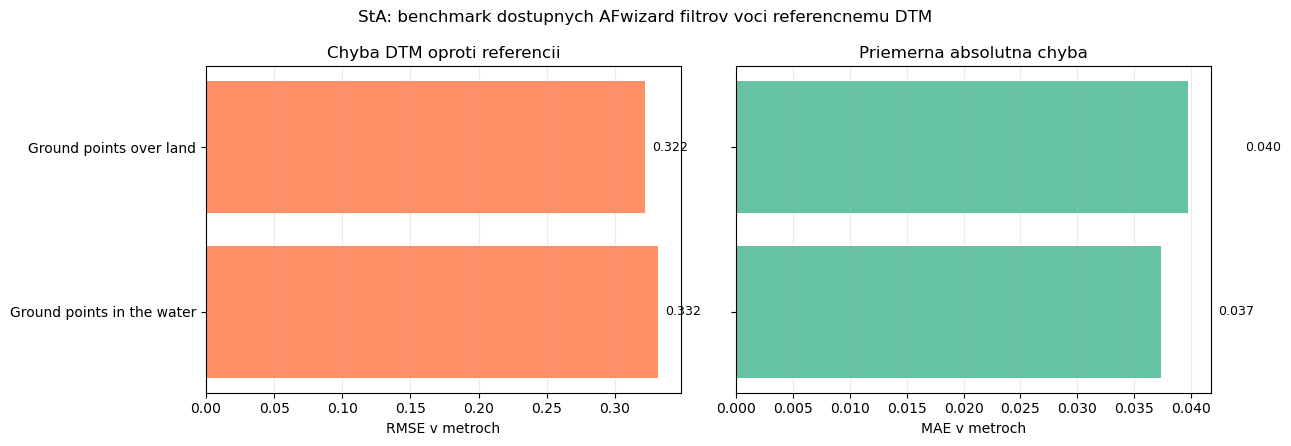

In [75]:
if STA_BENCHMARK_CSV.exists():
    plot_df = sta_benchmark_df.sort_values('rmse', ascending=True)
    y_positions = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    axes[0].barh(y_positions, plot_df['rmse'], color='#ff8f66')
    axes[0].set_yticks(y_positions)
    axes[0].set_yticklabels(plot_df['pipeline_title'])
    axes[0].invert_yaxis()
    axes[0].set_xlabel('RMSE v metroch')
    axes[0].set_title('Chyba DTM oproti referencii')
    axes[0].grid(axis='x', alpha=0.25)

    axes[1].barh(y_positions, plot_df['mae'], color='#66c2a5')
    axes[1].set_xlabel('MAE v metroch')
    axes[1].set_title('Priemerna absolutna chyba')
    axes[1].grid(axis='x', alpha=0.25)

    for ax, column in zip(axes, ['rmse', 'mae']):
        for y, value in zip(y_positions, plot_df[column]):
            ax.text(value + 0.005, y, f'{value:.3f}', va='center', fontsize=9)

    fig.suptitle('StA: benchmark dostupnych AFwizard filtrov voci referencnemu DTM')
    fig.tight_layout()
    out_png = OUTPUT_DIR / 'visualizations' / 'sta_benchmark_metrics.png'
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=180, bbox_inches='tight')
    print(f'Ulozene: {out_png}')
    show_once(fig)

Ulozeny obrazok: output/visualizations/sta_filters_before_after.png


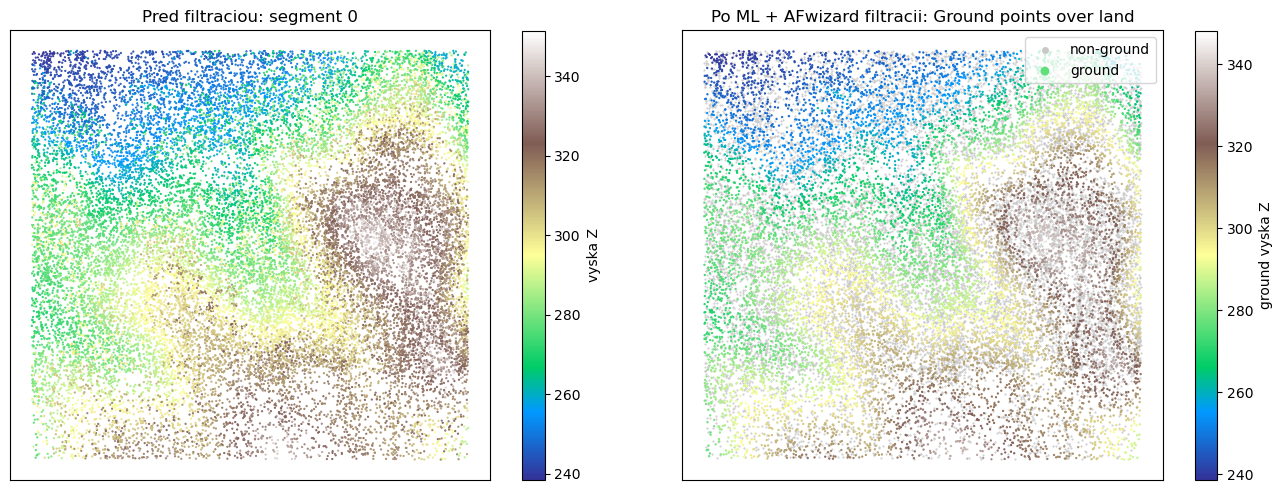

Ulozeny obrazok: output/visualizations/sta_filters_raster_before_after.png


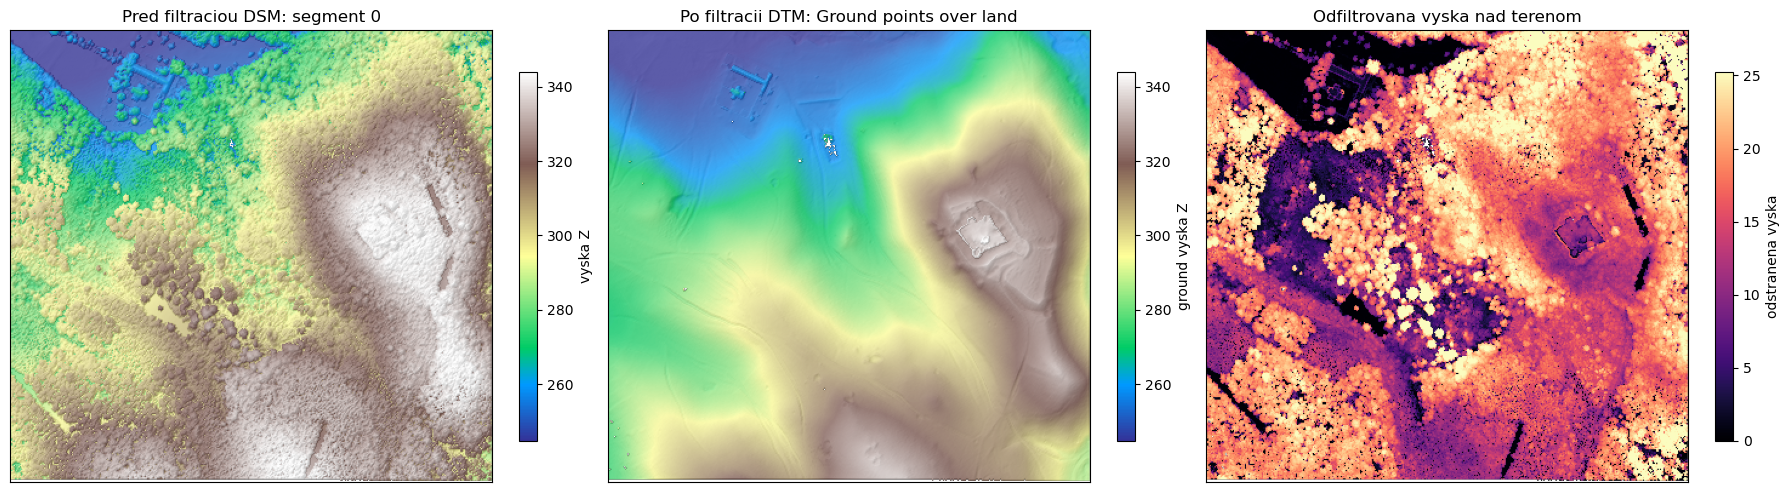

In [76]:
show_once(plot_filter_examples(
    raw_las_path=STA_LAS,
    filtered_las_path=STA_FILTERED,
    assigned_geojson_path=STA_ML_ASSIGNED,
    out_png=OUTPUT_DIR / 'visualizations' / 'sta_filters_before_after.png',
))

show_once(plot_raster_filter_examples(
    raw_las_path=STA_LAS,
    filtered_las_path=STA_FILTERED,
    assigned_geojson_path=STA_ML_ASSIGNED,
    resolution=2.0,
    out_png=OUTPUT_DIR / 'visualizations' / 'sta_filters_raster_before_after.png',
))

## 16. Zhrnutie pre obhajobu

Najdolezitejsie je povedat, ze model nenahradza samotny ground filter. Model automatizuje vyber vhodneho AFwizard filtra pre segment. AFwizard potom cez LASTools vykona realnu filtraciu point cloudu.

Pre PK data je overeny vysledok:

```text
veg -> Ground points over land
UW  -> Ground points in the water
F1  -> 1.0
IoU -> 1.0
```

To znamena, ze ML vyber filtrov dosiahol uplnu zhodu ground klasifikacie s referencnym PK vystupom.

Pre StA data model vybral `Ground points over land` s nizsou istotou okolo 54 %. Preto je vysledok oznaceny ako vhodny na kontrolu. Nasledny benchmark voci referencnemu StA DTM vsak potvrdil rovnaky filter ako najlepsi kandidat:

```text
Ground points over land     -> RMSE 0.322 m, MAE 0.040 m
Ground points in the water  -> RMSE 0.332 m, MAE 0.037 m
```

Lepsi level riesenia je teda kombinacia: ML automaticky navrhne filter, confidence threshold oznaci neistotu a kandidatny benchmark vie pri dostupnom referencnom DTM objektivne overit, ci ML vyber suhlasi s najlepsim filtrom.